<h1><center>ML Project (Ecommerce Analysis)</center></h1>
<center>The objective of this project is to demonstrate the analysis of ecommerce data. The project aims to show how ecommerce data can be visualised and machine learning can be applied to gain more insights from the data.</center>
<br>

<h3><center>By: Gee Jun Hui Leonidas Yunani</center></h3>
<center>Email: leonidas.gee@studio.unibo.it</center>
<center>Academic Year: 2021 / 2022</center>

In [1]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
import plotly.express as px
from pmdarima.arima import auto_arima
from datetime import timedelta
from geopy.geocoders import ArcGIS
geolocator = ArcGIS()

# Set the mode to online or offline
mode = 'offline' # 'online' # 'offline'

## Data Import

The [dataset](https://www.kaggle.com/olistbr/brazilian-ecommerce/home?select=olist_order_reviews_dataset.csv) used is provided by Olist, the largest department store in Brazilian marketplaces. Olist connects small businesses from all over Brazil to channels without hassle and with a single contract. Those merchants are able to sell their products through the Olist Store and ship them directly to the customers using Olist logistics partners.

The dataset has information of 100k orders from 2016 to 2018 made at multiple marketplaces in Brazil. The dataset represents real commercial data and has been anonymised with references to companies and partners being replaced with the names of Game of Thrones great houses.

In [2]:
# Load the datasets
customers = pd.read_csv('dataset/olist_customers_dataset.csv')
orders = pd.read_csv('dataset/olist_orders_dataset.csv')
items = pd.read_csv('dataset/olist_order_items_dataset.csv')
products = pd.read_csv('dataset/olist_products_dataset.csv')
categories = pd.read_csv('dataset/product_category_name_translation.csv')
payments = pd.read_csv('dataset/olist_order_payments_dataset.csv')

In [3]:
# Preview the customers dataset
print('Numbers of rows & columns: {}'.format(customers.shape))
print(list(customers.columns))

Numbers of rows & columns: (99441, 5)
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [4]:
# Preview the orders dataset
print('Numbers of rows & columns: {}'.format(orders.shape))
print(list(orders.columns))

Numbers of rows & columns: (99441, 8)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [5]:
# Preview the items dataset
print('Numbers of rows & columns: {}'.format(items.shape))
print(list(items.columns))

Numbers of rows & columns: (112650, 7)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [6]:
# Preview the products dataset
print('Numbers of rows & columns: {}'.format(products.shape))
print(list(products.columns))

Numbers of rows & columns: (32951, 9)
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [7]:
# Preview the categories dataset
print('Numbers of rows & columns: {}'.format(categories.shape))
print(list(categories.columns))

Numbers of rows & columns: (71, 2)
['product_category_name', 'product_category_name_english']


In [8]:
# Preview the payments dataset
print('Numbers of rows & columns: {}'.format(payments.shape))
print(list(payments.columns))

Numbers of rows & columns: (103886, 5)
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


## Data Preparation

The data is prepared by first merging all the tables using inner joins. The relevant columns are selected and then transformations are applied if necessary. The transformations include the simplification of the customer id using label encoding, the states are expanded into their full official names and the sales column is created using the price and orders column. 

In [9]:
# Inner join all the tables
data = customers.merge(orders, on='customer_id')
data = data.merge(items, on='order_id')
data = data.merge(products, on='product_id')
data = data.merge(categories, on='product_category_name')
data = data.merge(payments, on='order_id')
print('Number of rows & columns: {}'.format(data.shape))

Number of rows & columns: (115878, 31)


In [10]:
# Rearrange the columns
data = data[['order_purchase_timestamp', 'customer_unique_id', 'customer_state',    
             'product_category_name_english', 'payment_type', 'price', 'order_item_id']]

# Rename the columns
data.columns = ['Date', 'Customer', 'State', 'Product', 'Payment', 'Price', 'Orders']

In [11]:
# Replace the state codes with state names
states = {'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia', 
          'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás', 'MA': 'Maranhão', 
          'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 
          'PR': 'Paraná', 'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte', 
          'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina', 'SP': 'São Paulo', 
          'SE': 'Sergipe', 'TO': 'Tocantins'}

data['State'] = data['State'].replace(states)

In [12]:
# Change the customer id into unique integer keys
data['Customer'] = le.fit_transform(data['Customer'])

# Replace underscores with spaces
data['Product'] = data['Product'].str.replace('_', ' ')
data['Payment'] = data['Payment'].str.replace('_', ' ')

# Change strings to camel case
data['Product'] = data['Product'].str.title()
data['Payment'] = data['Payment'].str.title()

In [13]:
# Keep only the date part from date
data['Date'] = pd.to_datetime(data['Date']).dt.date

# Add a sales column
data['Sales'] = data['Orders'] * data['Price']

In [14]:
# Sort transactions by date
data = data.sort_values(by='Date', ignore_index=True)

# Preview the dataset
print('Number of rows & columns: {}'.format(data.shape))
data.head(3)

Number of rows & columns: (115878, 8)


,Date,Customer,State,Product,Payment,Price,Orders,Sales
0,2016-09-04,67670,Roraima,Furniture Decor,Credit Card,32.90,2,65.80
1,2016-09-04,67670,Roraima,Furniture Decor,Credit Card,39.99,1,39.99
2,2016-09-05,26676,Rio Grande do Sul,Telephony,Credit Card,59.50,1,59.50


## Data Visualisation

The data is then visualised based on the requirements of the marketing department. This includes the breakdown in customers and sales according to different categories.

### Customer by Payment

The customers can be divided into different groups based on their payment methods. In this case, 4 groups emerge: credit card, Boleto, voucher and debit card. It can be seen that a majority of payments are done using credit card, then followed by Boleto, which is a local payment system in Brazil.

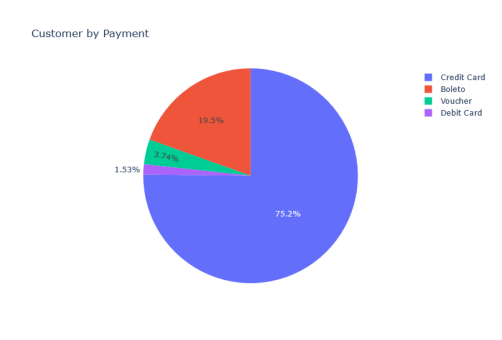

In [15]:
# Plot the customer by payment graph
if mode == 'online':
    # Get the customer by payment
    group_df = data[['Payment', 'Customer']].groupby('Payment').agg('nunique')
    customer_by_payment = pd.DataFrame()
    customer_by_payment['Payment'] = group_df.index
    customer_by_payment['Customer'] = group_df.values

    fig = px.pie(customer_by_payment, values='Customer', names='Payment', title='Customer by Payment')
    fig.show()
    
elif mode == 'offline':
    plt.figure(figsize=(14, 6))
    image = plt.imread('images/customer_by_payment.png')
    plt.axis('off')
    plt.imshow(image)

### Orders by Product

The orders can be divided by product to visualise the top products being sold via Olist. Products such as bed bath table, furniture decor and health beauty seem to be the best selling products.

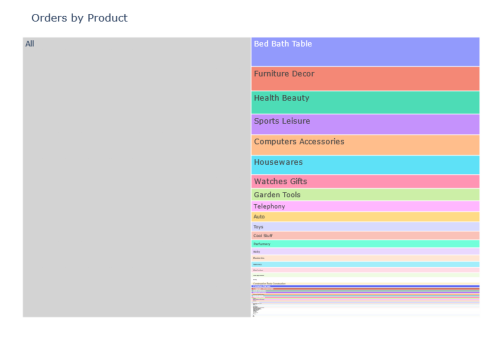

In [16]:
# Plot the orders by product graph
if mode == 'online':
    # Get the orders by product
    group_df = data[['Product', 'Orders']].groupby('Product').agg('sum')
    orders_by_product = pd.DataFrame()
    orders_by_product['Product'] = group_df.index
    orders_by_product['Orders'] = group_df.values

    fig = px.icicle(orders_by_product, values='Orders', path=[px.Constant('All'), 'Product'], title='Orders by Product')
    fig.update_traces(root_color="lightgrey")
    fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
    fig.show()
    
elif mode == 'offline':
    plt.figure(figsize=(14, 6))
    image = plt.imread('images/orders_by_product.png')
    plt.axis('off')
    plt.imshow(image)

### Sales by State

Using a bubble map, the location and sales volume from customers throughout the states in Brazil can be visualised. The longitude and latitude are first obtained using a geoencoder before being applied to the graph. It can be seen that the staes of São Paulo, Rio de Janeiro and Minas Gerais have the largest sales volume.

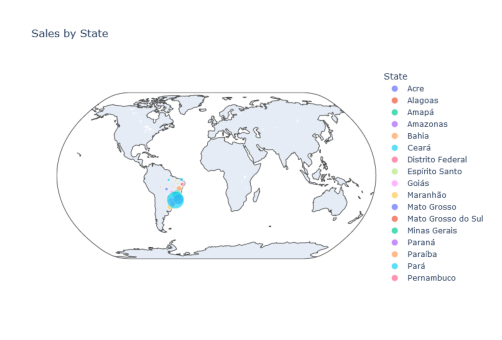

In [17]:
# Plot the sales by state graph
if mode == 'online':
    # Get the sales by state
    group_df = data[['State', 'Sales']].groupby('State').agg('sum')
    sales_by_state = pd.DataFrame()
    sales_by_state['State'] = group_df.index
    sales_by_state['Sales'] = group_df.values

    def get_location(args):
        location = geolocator.geocode(args[0] + ', Brazil')
        return pd.Series([args[0], location.longitude, location.latitude, args[1]])

    sales_by_state[['State', 'Longitude', 'Latitude', 'Sales']] = sales_by_state.apply(get_location, axis=1)

    fig = px.scatter_geo(sales_by_state, lon='Longitude', lat='Latitude',
                         color='State', hover_name='State', size='Sales',
                         projection='natural earth', title='Sales by State')
    fig.show()
    
elif mode == 'offline':
    plt.figure(figsize=(14, 6))
    image = plt.imread('images/sales_by_state.png')
    plt.axis('off')
    plt.imshow(image)

## Time Series Forecasting

A time-series is a sequence of data that is reocrded at regular time intervals (daily, weekly, monthly, etc.). An important usage of time-series data is in forecasting. For businesses, forecasting can be used to predict the direction of future sales growth over a specfied time frame. Knowing the probable direction of sales growth will allow a company to set more easily plan for inventory purchases and set overall sales targets. For this dataset, time-series forecasting is used to predict weekly sales growth over a period of 8 weeks.

### Predicting Sales Growth

Using ARIMA, a model can be trained to forecast the future weekly sales over a future period of 8 weeks. Auto ARIMA is used to find the optimal values for the model using data from January, 2017 to August, 2018.

- Auto-Regressive (p) -> Number of autoregressive terms.

- Integrated (d) -> Number of differencing needed for stationarity.

- Moving Average (q) -> Number of lagged forecast errors.

In [18]:
# Get the number of weekly sales
data['Date'] = pd.to_datetime(data['Date']) - pd.to_timedelta(7, unit='d')
group_df = data[['Date', 'Sales']].groupby(pd.Grouper(key='Date', freq='W-MON')).agg('sum')
weekly_sales = pd.DataFrame()
weekly_sales['Date'] = group_df.index
weekly_sales['Date'] = pd.to_datetime(weekly_sales['Date'])
weekly_sales['Sales'] = group_df.values

In [19]:
# Keep rows starting from 2017 and ending in August, 2018
weekly_sales = weekly_sales[(weekly_sales['Date'].dt.year >= 2017) & (weekly_sales['Date'] <= '2018-07-30')]
weekly_sales = weekly_sales.reset_index(drop=True)
weekly_sales

,Date,Sales
0,2017-01-02,7030.05
1,2017-01-09,16959.61
2,2017-01-16,33800.16
3,2017-01-23,77808.35
4,2017-01-30,71230.95
...,...,...
78,2018-07-02,174093.09
79,2018-07-09,208739.37
80,2018-07-16,266542.56
81,2018-07-23,281070.82


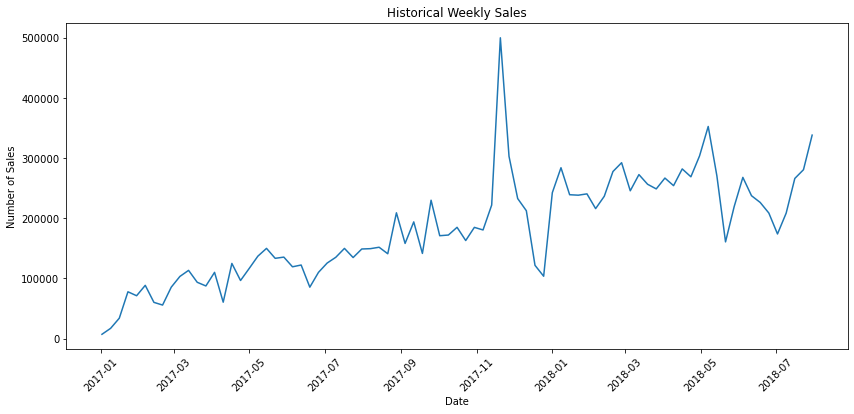

In [20]:
# Plot the graph of the weekly sales
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales['Date'], weekly_sales['Sales'])
plt.xticks(rotation=45)
plt.title('Historical Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Number of Sales')
plt.show()

In [21]:
def get_forecast(data, y, n_periods):
    arima_model = auto_arima(data[y], stepwise=False, parallel=True)
    
    print(f"Best Model Parameters: {arima_model.order}")
    print(f"Best AIC Score: {arima_model.aic():.2f}")
    print(f"Best BIC Score: {arima_model.bic():.2f}")
    
    predictions = arima_model.predict(n_periods=n_periods)

    result = data.copy()
    result['Forecasted'] = False

    for value in predictions:
        last_row = result.loc[len(result)-1]
        result.loc[len(result)] = [last_row['Date'] + timedelta(days=7), round(value), True]
    
    return result

Best Model Parameters: (2, 1, 3)
Best AIC Score: 2010.64
Best BIC Score: 2027.48


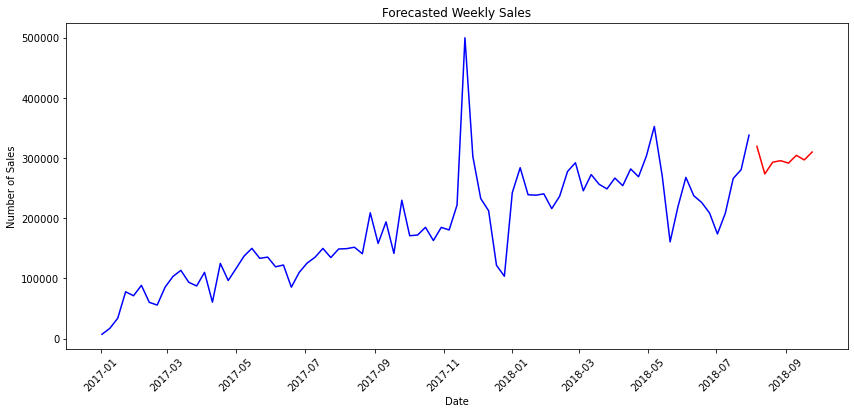

In [22]:
# Forecast future weekly sales for 8 weeks
sales_forecast = get_forecast(weekly_sales, 'Sales', 8)

# Plot the graph of the forecasted weekly sales
X1 = sales_forecast[sales_forecast.Forecasted == False]
X2 = sales_forecast[sales_forecast.Forecasted == True]

plt.figure(figsize=(14, 6))

plt.plot(X1['Date'], X1['Sales'], 'b')
plt.plot(X2['Date'], X2['Sales'], 'r')

plt.title('Forecasted Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.show()

## Conclusion

The project serves as a small representation of how data science and machine learning is applied in an industrial setting. A sample dataset is initially prepared using ETL (Extract, Transform, Load) methods before further descriptive and predict analysis is applied using dashboards and machine learning. In this case, separate graphs are used instead of a unified dashboard for a simpler integration with the Jupyter notebook.